In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Je cherche à identifier les facteurs pouvant expliquer le churn, c’est-à-dire la perte de clients.

Le dataset provient d’une entreprise simulée de services télécom proposant des abonnements à ses clients.

Dans ce contexte, je vais m’intéresser à trois axes qui me semblent particulièrement pertinents :  

Contract : permet de comprendre la durée d’engagement des clients et leur échéance de renouvellement, ce qui peut influencer le churn.  
Tenure : correspond à l’ancienneté du client, un indicateur potentiel de fidélité.  
MonthlyCharges : représente le montant payé mensuellement par le client, pouvant refléter une sensibilité au prix.  

Ces trois variables devraient, selon mon intuition, être corrélées au churn.

Je vais donc commencer par analyser la distribution de la variable cible afin d’évaluer l’équilibre des classes dans le dataset, avant d’explorer ces différentes variables plus en détail.

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True) *100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

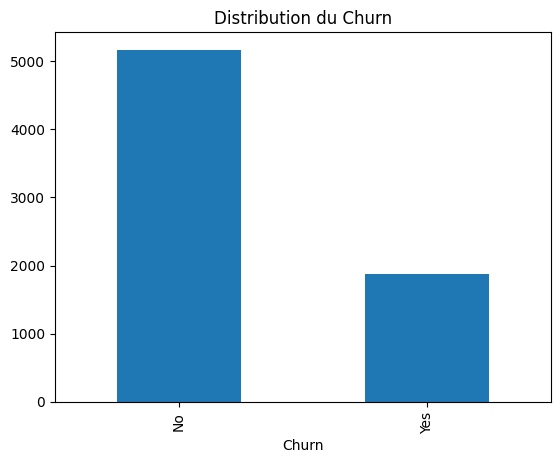

In [14]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribution du Churn")
plt.show()

Cette première exploration montre que la cible est déséquilibrée, avec environ 73 % des clients qui ne sont pas en situation de churn.
Ce déséquilibre devra être pris en compte lors de la construction et de l’évaluation des modèles de machine learning.

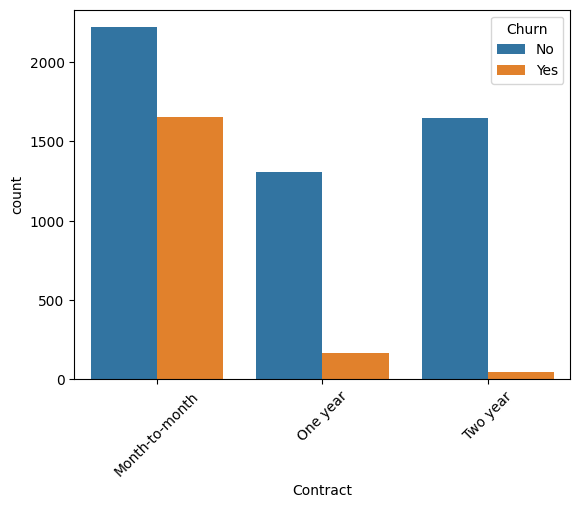

In [16]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.xticks(rotation=45)
plt.show()

Ce graphique me permet de voir que le churn est bien plus important avec des contrats renouvelable chaque mois.

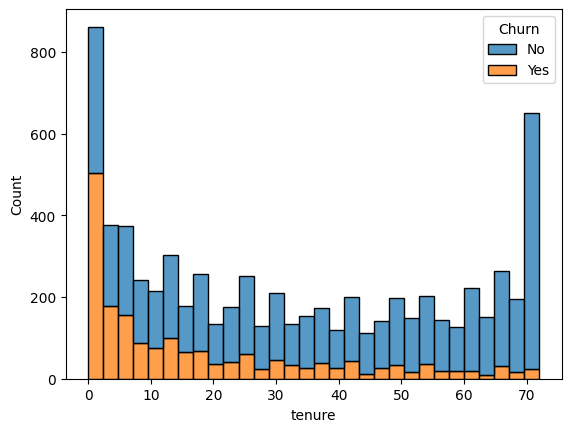

In [23]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="stack")
plt.show()

Celui ci me permet de distingué une baisse du churn significative en fonction de l'ancienneté.

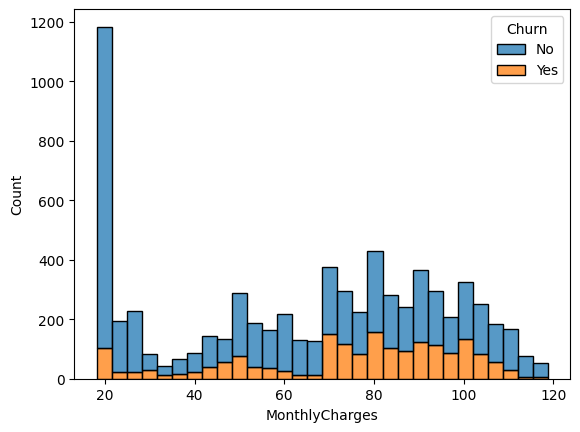

In [ ]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, multiple="stack")
plt.show()

Pour finir mes trois axes d'exploration, ce dernier graphique me montre que le churn est plus important à partir des 70 de charges mensuelles, je note quand même un très faible quantité de churn sur les abonnement les plus onéreux.

Je vois avec les précédentes analyses, qu'on voit un patern assez nettement, j'ai la curiosité d'essayer d'en trouver d'autres, je vais m'intéréssé au PayementMethod et à l'internet service, je me doute que le genre par exemple ne sera pas très parlant, je le ferai quand même pour vérifié mon intuition.

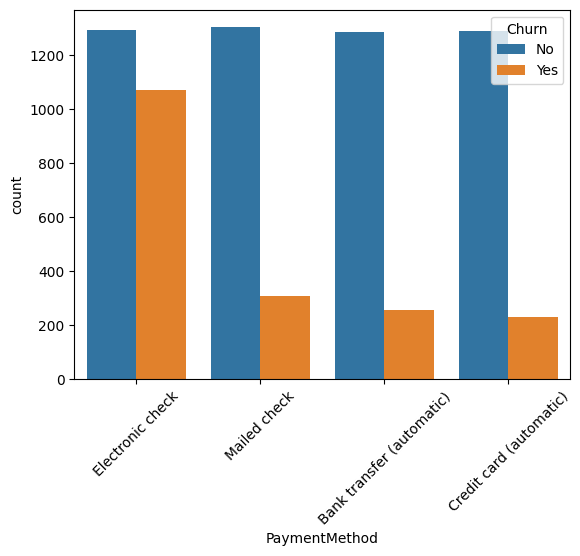

In [ ]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=45)
plt.show()

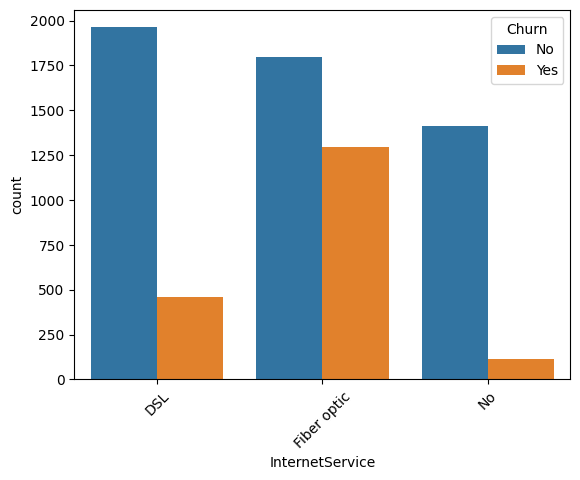

In [ ]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.xticks(rotation=45)
plt.show()

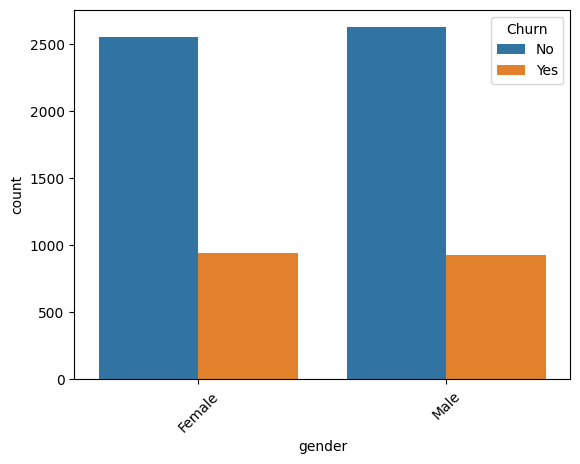

In [28]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.xticks(rotation=45)
plt.show()

Comme prévu, le genre n'a pas de reelle incidence, en revanche je vois bien deux nouvelles informations :  
-L'électronique check est la cause la plus grande de churn, paiement non automatisé, clients moins fiables.  
-Les clients sous fibre optique chrun plus, cela peux s'expliqué par des problèmes de qualitées ou des attentes plus élevé, je pars de cette supposition en prenant mon cas, mon ancien opérateur avait souvent des problèmes sur ma fibre et lors de l'appel au support mes problèmes n'étaient pas souvent résolu, j'en viens à me demander, par expériences personnelles si le TechSupport ne serait pas un bon indicateur.  

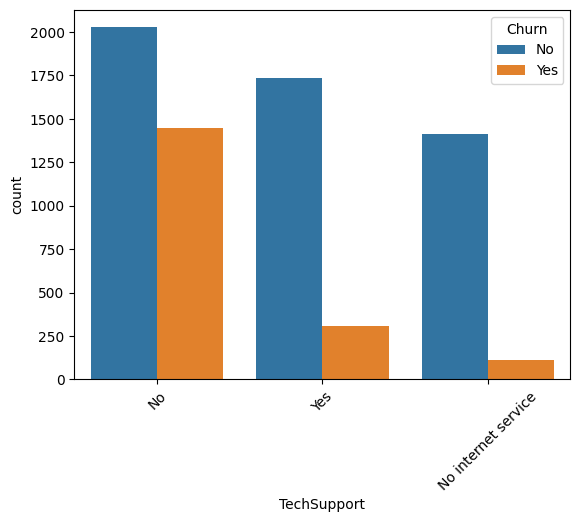

In [29]:
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.xticks(rotation=45)
plt.show()

Effectivement, je ne devais pas être le seul a être frustré par le service client, mon intuition et mon expérience personelles m'on permet de ne pas passer à côté de cet indicateur.

# Points clé :  

-Le churn du data set est déséquilibrés ( ~73% non-churn vs ~27% churn)  
-Les clients qui renouvelle leurs contrat chaque mois on tendance à être churn.  
-Les clients de longue dates churn moins.  
-Les clients associés a de plus grosse charges mensuelles churn plus facilement.  
-L'electronic check est la méthode de paiement la plus fortement corrélé avec le churn.  
-Les clients fibre optique sont plus souvent en churn que les autres.  
-Quand il y a un service technique, les clients churn beaucoup moins.  